# **Gala projekts: Adult Census Income**

## Klasterizācija + modeļu novērtēšana

### Darba mērķis
Šī darba mērķis ir, izmantojot **Adult Census Income** datus, 
(1) izveidot interpretējamus **personu segmentus** ar klasterizāciju
(2) uzbūvēt **klasifikācijas modeļus**, kas prognozē, vai personas ienākumi pārsniedz **50K** gadā (`income`: `>50K` vs `<=50K`).plain.pdf)

### Ko tieši darīšu (darba plāns)

**A daļa – Klasterizācija (K‑Means):**
1. Izvēlēšos 3–5 skaitliskas iezīmes, kas raksturo sociālekonomisko profilu (vecums, izglītība, kapitāla rādītāji, darba stundu skaits). 
2. Normalizēšu pazīmes ar `StandardScaler`, jo K‑Means izmanto attālumus un ir jūtīgs pret mērogu. 
3. Izvēlēšos klasteru skaitu ar **Elbow** metodi (inerces analīze).  
4. Apmācīšu K‑Means (K=4), vizualizēšu klasterus ar **PCA**, aprēķināšu profilu vidējās vērtības un sniegšu interpretācijas + rekomendācijas. [1]

**B daļa – Klasifikācija:**
1. Pārveidošu mērķa mainīgo `income` uz bināru `income_bin` (0/1). 
2. Izveidošu `Pipeline` ar `ColumnTransformer`: skaitliskajām pazīmēm `StandardScaler`, kategoriskajām `OneHotEncoder`. Tas novērš **data leakage**, jo transformācijas tiek apmācītas tikai treniņa daļā katrā CV iterācijā. 
3. Novērtēšu modeļus ar **F1** (piemērota nesabalansētām klasēm) un salīdzināšu **vienu sadalījumu** pret **5‑fold cross‑validation**. 
4. Veikšu **GridSearchCV** Random Forest un Logistic Regression (≥2 parametri), zīmēšu ROC‑AUC un PR līknes, optimizēšu slieksni pēc F1 un interpretēšu kļūdas ar confusion matrix. 
5. Veikšu interpretējamību: **RF feature importance** un **LR koeficientu** analīzi.

### Sagaidāmais rezultāts
- Praktiski interpretējami klasteri (segmenti) ar īsiem profilu aprakstiem un rekomendācijām.  
- Salīdzināti klasifikatori (RF, LR, Linear SVC) un pamatots, kurš ir piemērotāks atbilstoši mērķim (piem., minimizēt FP vai FN). [

### Skripta struktūra

1) **Stabila datu ielāde (lokāli → internets)**  
   - Vispirms mēģina nolasīt lokālo failu *adult_full_48842.csv* (pilnā UCI Adult datu kopa).  
   - Ja faila nav, ielādē no OpenML ar `fetch_openml('adult', version=2)` un **automātiski saglabā**  
     `adult_full_48842.csv` tajā pašā mapē, lai nākamreiz var strādāt bez interneta.

> **Avota konteksts:** UCI Adult datu kopai ir **48 842** ieraksti un **14** pazīmes (+ mērķis `income`).

2) **Projekta struktūra**

   **A) Klasterizācija (K-Means)**  
   - 3–5 skaitlisku iezīmju izvēle un normalizācija  
   - Elbow metode K izvēlei  
   - K-Means ar K=4, PCA vizualizācija  
   - Klasteru profili (vidējās vērtības) + heatmap  
   - Klasteru interpretācija + rekomendācijas (ģenerēta no faktiskajiem profiliem)

   **B) Klasifikācija**  
   - mērķa mainīgais `income` → `income_bin` (0/1)  
   - Pipeline (ColumnTransformer: StandardScaler + OneHotEncoder)  
   - Viens split vs Cross-validation (cv=5) ar F1  
   - GridSearchCV (RandomForest un LogisticRegression) + heatmap  
   - ROC-AUC līknes salīdzinājums  
   - Precision–Recall (PR) līkne + Average Precision (AP)  
   - Sliekšņa optimizācija pēc F1 (RF)  
   - Confusion matrix interpretācija  
   - Interpretējamība: RF feature importance + LR koeficienti

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [5]:
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

In [6]:
sns.set()
RANDOM_STATE = 42

## 0. Palīgfunkcijas (ielāde, tīrīšana, feature nosaukumi, interpretācijas)

In [7]:
def load_adult_full() -> pd.DataFrame:
    """Datu ielāde: lokāli adult_full_48842.csv -> ja nav, OpenML un saglabā.

    Kāpēc tā?
    - Lokālais fails nodrošina reproducējamību bez interneta.
    - Ja faila nav, OpenML ļauj iegūt pilno Adult kopu un mēs to uzreiz saglabājam.
    """

    full_fp = os.path.join(os.getcwd(), 'adult_full_48842.csv')

    if os.path.exists(full_fp):
        df0 = pd.read_csv(full_fp, na_values=['?'], skipinitialspace=True)
        print('✅ Dati ielādēti lokāli: adult_full_48842.csv')
        return df0

    print('ℹ️ Lokālais adult_full_48842.csv nav atrasts. Mēģinu ielādēt no OpenML...')
    from sklearn.datasets import fetch_openml

    adult = fetch_openml('adult', version=2, as_frame=True)
    df0 = adult.frame

    # OpenML mērķa kolonna mēdz būt 'class'
    if 'class' in df0.columns and 'income' not in df0.columns:
        df0 = df0.rename(columns={'class': 'income'})

    # income var būt ar punktu (>50K.) — noņemam
    if 'income' in df0.columns:
        df0['income'] = df0['income'].astype('string').str.strip().str.replace('.', '', regex=False)

    df0.to_csv(full_fp, index=False)
    print('✅ OpenML dati ielādēti un saglabāti lokāli: adult_full_48842.csv')
    return df0

In [8]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Saskaņo UCI/OpenML kolonnu nosaukumus uz "punktu" formātu, lai kods būtu stabils.

    Piemērs:
    - education-num -> education.num
    - hours-per-week -> hours.per.week
    """

    rename_map = {
        'education-num': 'education.num',
        'marital-status': 'marital.status',
        'capital-gain': 'capital.gain',
        'capital-loss': 'capital.loss',
        'hours-per-week': 'hours.per.week',
        'native-country': 'native.country',
    }
    return df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

In [9]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Datu tīrīšana un trūkstošo vērtību apstrāde.

    Ko darām:
    1) '?' -> NaN
    2) Tekstu kolonnām noņemam sākuma/beigu atstarpes (lai kategorijas nesadalītos ' Private' vs 'Private').
    3) Kategoriskajās kolonnās NaN aizvietojam ar modu.
    4) Skaitliskajās (ja gadās) NaN aizvietojam ar mediānu.

    Kāpēc:
    - OneHotEncoder nestrādā ar NaN bez papildu soļiem.
    - Moda ir vienkārša un interpretējama imputācijas bāzes pieeja kategorijām.
    """

    df = df.replace('?', np.nan)

    obj_cols = df.select_dtypes(include=['object', 'string']).columns
    for c in obj_cols:
        # 'string' dtype saglabā NaN kā NA, nevis pārvērš par tekstu 'nan'
        df[c] = df[c].astype('string').str.strip()

    if 'income' in df.columns:
        df['income'] = df['income'].astype('string').str.strip().str.replace('.', '', regex=False)

    missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    print('\nTrūkstošo vērtību % (tikai kolonnas ar trūkumiem):')
    print(missing_pct[missing_pct > 0].round(3))

    # kategoriskie -> moda
    cat_cols = df.select_dtypes(include=['object', 'string']).columns
    for c in cat_cols:
        if df[c].isnull().any():
            df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

    # skaitliskie -> mediāna
    num_cols = df.select_dtypes(exclude=['object', 'string']).columns
    for c in num_cols:
        if df[c].isnull().any():
            df[c] = df[c].fillna(df[c].median())

    print('Pēc aizvietošanas (NaN kopskaits):', int(df.isnull().sum().sum()))
    return df

In [10]:
def get_feature_names(preprocessor: ColumnTransformer, X_df: pd.DataFrame):
    """Atgriež feature nosaukumus pēc ColumnTransformer, lai varētu interpretēt importance/koeficientus."""
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        # fallback
        try:
            num_cols = X_df.select_dtypes(exclude=['object', 'string']).columns
            cat_cols = X_df.select_dtypes(include=['object', 'string']).columns
            ohe = None
            for name, trans, cols in preprocessor.transformers_:
                if name == 'cat':
                    ohe = trans
                    break
            if ohe is None:
                return None
            cat_names = ohe.get_feature_names_out(cat_cols)
            return np.concatenate([np.array([f'num__{c}' for c in num_cols]), cat_names])
        except Exception:
            return None

In [11]:
def interpret_clusters(cluster_profiles: pd.DataFrame, cluster_sizes: pd.Series):
    """Klasteru interpretācijas no faktiskajiem profiliem.

    Piezīme:
    - Segmentu nosaukumi tiek izvēlēti pēc dominējošiem raksturlielumiem (gain/loss/age/edu/hours).
    - Tāpēc interpretācijas automātiski pielāgojas, ja mainās dati vai K.
    """

    print('\n' + '-' * 80)
    print('2.7. Klasteru interpretācija + rekomendācijas')
    print('-' * 80)

    for cl in cluster_profiles.index:
        row = cluster_profiles.loc[cl]
        age = float(row['age'])
        edu = float(row['education.num'])
        gain = float(row['capital.gain'])
        loss = float(row['capital.loss'])
        hrs = float(row['hours.per.week'])
        n = int(cluster_sizes.loc[cl])

        if gain >= 50000:
            name = 'Ļoti augsta kapitāla pieauguma (high-value) segments'
            desc = (f"Mazs, bet izteikts segments (n={n}) ar ļoti augstu capital.gain ({gain:.0f}), "
                    f"augstāku izglītību (education.num={edu:.2f}) un lielāku darba laiku (hours/week={hrs:.2f}).")
            reco = 'Mērķēti piedāvājumi/atbalsts augsta ienākuma profilam; izmantot kā high-value references grupu.'
        elif loss >= 500:
            name = 'Kapitāla zaudējumu segments'
            desc = (f"Segmentā (n={n}) izteikti augsts capital.loss ({loss:.2f}) un zems capital.gain ({gain:.2f}). "
                    f"Vecums {age:.2f}, hours/week {hrs:.2f}.")
            reco = 'Finanšu riska mazināšana (finanšu pratība, konsultācijas, riska pārvaldība).'
        elif age < 35 and edu < 10 and hrs < 40:
            name = 'Jaunie / zemāka izglītība / mazāk darba stundu'
            desc = (f"Jaunāks segments (n={n}) ar zemāku izglītību (education.num={edu:.2f}) un mazāk stundu (hours/week={hrs:.2f}); "
                    f"zemi kapitāla rādītāji (gain={gain:.2f}, loss={loss:.2f}).")
            reco = 'Apmācības/izglītības programmas, karjeras konsultācijas, kvalifikācijas celšana.'
        else:
            name = 'Pieredzējušie ar mērenu kapitāla pieaugumu'
            desc = (f"Stabilāks segments (n={n}) ar age={age:.2f}, hours/week={hrs:.2f}, "
                    f"mērenu gain={gain:.2f} un zemu loss={loss:.2f}; education.num={edu:.2f}.")
            reco = 'Uzturēt produktivitāti un veicināt ilgtermiņa finanšu plānošanu.'

        print(f"\nKlasteris {cl} — \"{name}\"")
        print('Apraksts:', desc)
        print('Rekomendācija:', reco)

## 1. Datu ielāde un kvalitātes pārbaude

In [12]:
print('=' * 88)
print('1) DATU IELĀDE UN KVALITĀTES PĀRBAUDE')
print('=' * 88)

1) DATU IELĀDE UN KVALITĀTES PĀRBAUDE


In [13]:
# Ielādējam (lokāli -> OpenML)
df = load_adult_full()

✅ Dati ielādēti lokāli: adult_full_48842.csv


In [14]:
# Saskaņojam kolonnu nosaukumus
df = standardize_columns(df)

In [15]:
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print('Kolonnas:', list(df.columns))

Datu kopa: 48842 rindas, 15 kolonnas
Kolonnas: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [16]:
# Tīrīšana/imputācija
df = clean_data(df)


Trūkstošo vērtību % (tikai kolonnas ar trūkumiem):
occupation        5.751
workclass         5.731
native.country    1.755
dtype: float64
Pēc aizvietošanas (NaN kopskaits): 0


In [17]:
if int(df.isnull().sum().sum()) != 0:
    raise AssertionError('Pēc apstrādes joprojām ir NaN!')

### Datu ielāde un kvalitātes pārbaude — rezultātu interpretācija

### (1) Datu avots un apjoms
Datu kopa tika ielādēta no lokālā faila `adult_full_48842.csv` (ja pieejams), pretējā gadījumā no OpenML ar automātisku saglabāšanu lokāli. Kopējais apjoms: **48 842 rindas** un **15 kolonnas** (14 pazīmes + mērķis `income`). 

### (2) Trūkstošās vērtības un to apstrāde
Datu kopā trūkstošās vērtības bija koncentrētas galvenokārt kategoriskajās pazīmēs:
- `occupation` ~ **5.751%**  
- `workclass` ~ **5.731%**  
- `native.country` ~ **1.755%** 

Trūkstošie ieraksti (`?`) tika pārvērsti uz `NaN`, pēc tam:
- **kategoriskajās kolonnās** aizvietoti ar **modu** (visbiežākā vērtība),
- **skaitliskajās kolonnās** (ja būtu nepieciešams) aizvietoti ar **mediānu**.
Pēc apstrādes trūkstošo vērtību skaits kļuva **0**, tātad datu kopa ir gatava modelēšanai bez rindu dzēšanas.

### (3) Kāpēc šāda imputācija ir pamatota
- Moda kategoriskajiem datiem ir vienkāršs un interpretējams bāzes risinājums, kas saglabā datu apjomu un neizmet novērojumus.  
- `OneHotEncoder` un modeļi parasti strādā stabilāk, ja nav `NaN`, tāpēc imputācija palīdz izvairīties no tehniskām problēmām un datu zuduma. 

### (4) Secinājumi (Datu sagatavošana)
1. Datu kopa veiksmīgi ielādēta pilnā apjomā (48 842 rindas), nodrošinot atbilstību klasiskajam Adult datu kopas aprakstam.  
2. Trūkstošās vērtības galvenokārt bija kategoriskajos laukos un pēc imputācijas **NaN=0**, tātad modelēšana var notikt korekti un reproducējami. 
3. Datu tīrīšana (strip, `?→NaN`, imputācija) samazina risku, ka kategorijas “sadalās” (piem., ` Private` vs `Private`) un uzlabo One‑Hot kodēšanas kvalitāti. 

## 2. A DAĻA — KLASTERIZĀCIJA (K-MEANS)

In [18]:
print('\n' + '=' * 88)
print('2) A DAĻA — KLASTERIZĀCIJA (K-MEANS)')
print('=' * 88)


2) A DAĻA — KLASTERIZĀCIJA (K-MEANS)


In [19]:
# 2.1 Iezīmju izvēle (3–5 skaitliskas)
cluster_features = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
missing_cols = [c for c in cluster_features if c not in df.columns]
if missing_cols:
    raise ValueError(f"Trūkst kolonnas klasterizācijai: {missing_cols}.")

In [20]:
print('Klasterizācijai izmantotās iezīmes:', cluster_features)
X_cluster = df[cluster_features].copy()
print(X_cluster.describe().T)

Klasterizācijai izmantotās iezīmes: ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
                  count         mean          std   min   25%   50%   75%  \
age             48842.0    38.643585    13.710510  17.0  28.0  37.0  48.0   
education.num   48842.0    10.078089     2.570973   1.0   9.0  10.0  12.0   
capital.gain    48842.0  1079.067626  7452.019058   0.0   0.0   0.0   0.0   
capital.loss    48842.0    87.502314   403.004552   0.0   0.0   0.0   0.0   
hours.per.week  48842.0    40.422382    12.391444   1.0  40.0  40.0  45.0   

                    max  
age                90.0  
education.num      16.0  
capital.gain    99999.0  
capital.loss     4356.0  
hours.per.week     99.0  


In [21]:
# 2.2 Normalizācija (K-Means ir jutīgs pret mērogu)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [22]:
# 2.3 Elbow metode
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

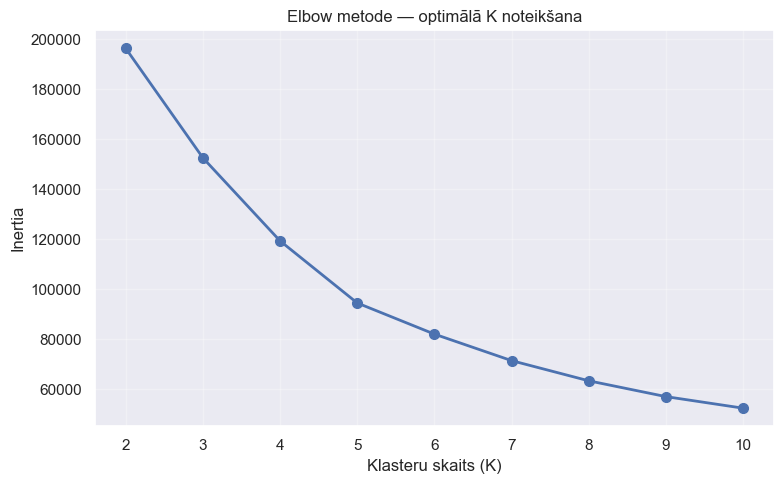

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
print('\nElbow interpretācija: izvēlamies K vietā, kur inerces kritums sāk izlīdzināties (mazāks ieguvums no papildu klasteriem).')


Elbow interpretācija: izvēlamies K vietā, kur inerces kritums sāk izlīdzināties (mazāks ieguvums no papildu klasteriem).


In [25]:
# 2.4 K-Means treniņš
K = 4
kmeans_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

In [26]:
print('\nKlasteru sadalījums (K=4):')
print(df['Cluster'].value_counts().sort_index())


Klasteru sadalījums (K=4):
Cluster
0    23162
1      244
2     2238
3    23198
Name: count, dtype: int64


In [27]:
# 2.5 PCA vizualizācija
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

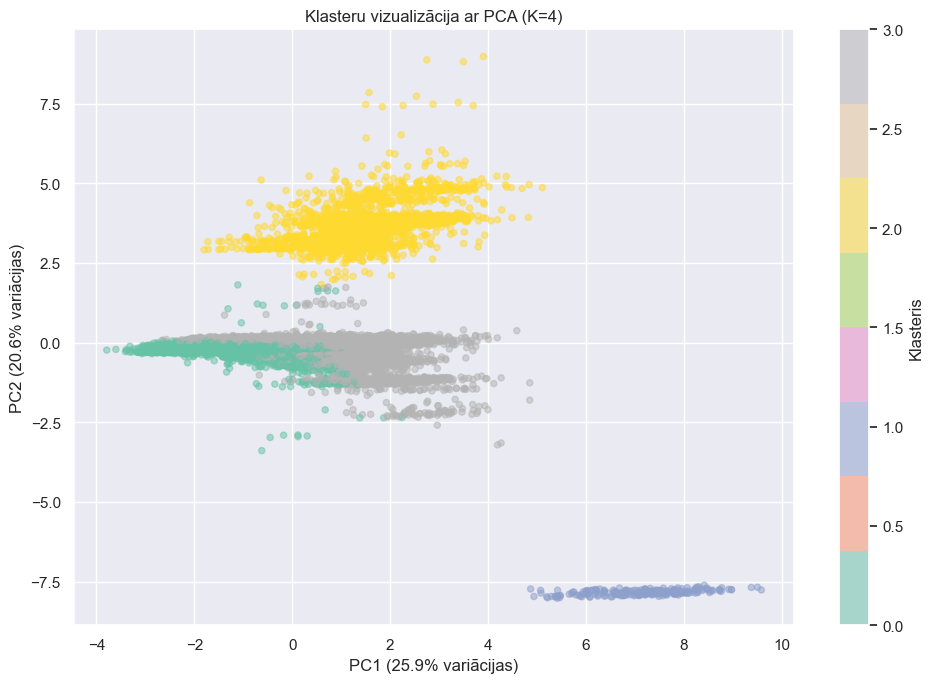

In [28]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)")
plt.title(f"Klasteru vizualizācija ar PCA (K={K})")
plt.tight_layout()
plt.show()

In [29]:
# 2.6 Profili + heatmap
cluster_profiles = df.groupby('Cluster')[cluster_features].mean().round(2)
cluster_sizes = df['Cluster'].value_counts().sort_index()

In [30]:
print('\nKlasteru profili (vidējās vērtības):')
print(cluster_profiles)


Klasteru profili (vidējās vērtības):
           age  education.num  capital.gain  capital.loss  hours.per.week
Cluster                                                                  
0        28.11           9.38        203.51          0.37           36.62
1        46.61          13.02      99999.00          0.00           50.48
2        41.78          11.00          0.00       1898.38           43.34
3        48.77          10.65       1016.92          0.72           43.83


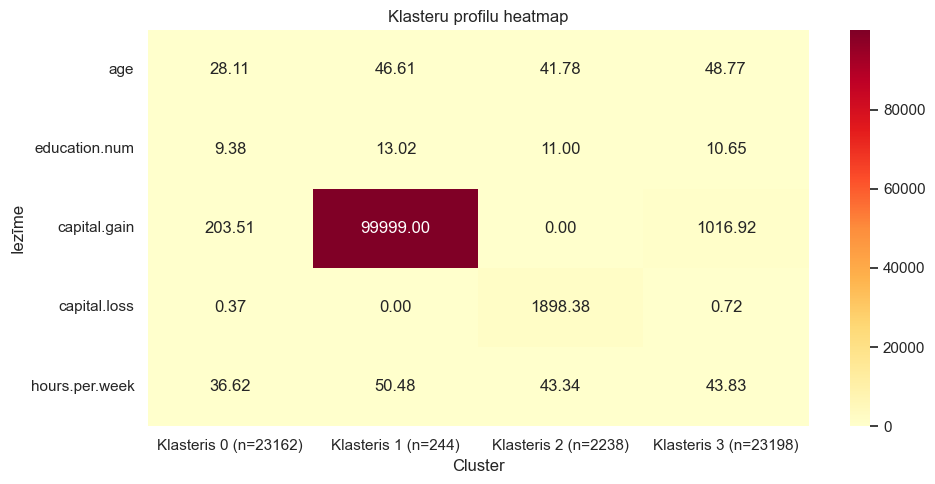

In [31]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=[f"Klasteris {i} (n={cluster_sizes[i]})" for i in range(K)]
)
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

In [32]:
# 2.7 Interpretācijas
interpret_clusters(cluster_profiles, cluster_sizes)


--------------------------------------------------------------------------------
2.7. Klasteru interpretācija + rekomendācijas
--------------------------------------------------------------------------------

Klasteris 0 — "Jaunie / zemāka izglītība / mazāk darba stundu"
Apraksts: Jaunāks segments (n=23162) ar zemāku izglītību (education.num=9.38) un mazāk stundu (hours/week=36.62); zemi kapitāla rādītāji (gain=203.51, loss=0.37).
Rekomendācija: Apmācības/izglītības programmas, karjeras konsultācijas, kvalifikācijas celšana.

Klasteris 1 — "Ļoti augsta kapitāla pieauguma (high-value) segments"
Apraksts: Mazs, bet izteikts segments (n=244) ar ļoti augstu capital.gain (99999), augstāku izglītību (education.num=13.02) un lielāku darba laiku (hours/week=50.48).
Rekomendācija: Mērķēti piedāvājumi/atbalsts augsta ienākuma profilam; izmantot kā high-value references grupu.

Klasteris 2 — "Kapitāla zaudējumu segments"
Apraksts: Segmentā (n=2238) izteikti augsts capital.loss (1898.38) un zems 

## A daļa — Klasterizācija (K‑Means) — rezultātu interpretācija

### (1) Izvēlētās iezīmes un normalizācija
Klasterizācijai tika izmantotas 5 skaitliskas pazīmes:  
`age`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`.  
Šīs pazīmes raksturo vecumu, izglītību, kapitāla ieguvumus/zaudējumus un darba slodzi, kas intuitīvi veido sociālekonomiskus profilus. 

Tika veikta normalizācija ar `StandardScaler`, jo K‑Means balstās uz Eiklīda attālumiem un bez mērogošanas pazīmes ar lielām vērtībām (piem., `capital.gain`) dominētu klasterizāciju. 

### (2) K izvēle: Elbow metode
Inerces analīze (K=2..10) tika izmantota, lai atrastu “elkoni” – punktu, kur pēc K palielināšanas inerces kritums kļūst lēnāks. Šajā projektā tika izvēlēts **K=4** kā kompromiss starp segmentu atšķiramību un modeļa vienkāršību. 

### (3) Klasteru sadalījums (K=4)
Iegūtais klasteru lielums:
- Klasteris 0: **23162**
- Klasteris 1: **244**
- Klasteris 2: **2238**
- Klasteris 3: **23198** 

Interpretācija: redzams viens ļoti mazs segments (Klasteris 1), kas norāda uz ļoti specifisku profilu (outlier tipa grupa), un divi lielāki “pamata” segmenti (0 un 3). 

### (4) PCA vizualizācija
PCA tika izmantota, lai 5D telpu projicētu uz 2 komponentēm (PC1/PC2) un vizuāli novērtētu klasteru atdalījumu. PCA neuzlabo klasterizāciju, bet palīdz interpretācijā (vai segmenti vispār veido “mākonīšus”). 

### (5) Klasteru profili (vidējās vērtības)
Iegūtie profili (vidējās vērtības) parādīja atšķirīgus sociālekonomiskus tipus: 

- **Klasteris 0 — “Jaunie / zemāka izglītība / mazāk darba stundu”**  
  Vidēji jaunāks (age≈28.11), zemāka izglītība (education.num≈9.38), mazāk stundu (≈36.62), zemi kapitāla rādītāji.  
  **Rekomendācija:** apmācības, kvalifikācijas celšana, karjeras konsultācijas.
  
- **Klasteris 1 — “Ļoti augsta kapitāla pieauguma (high‑value) segments”**
    Ļoti augsts `capital.gain` (≈99999), augstāka izglītība (≈13.02), ļoti liels darba laiks (≈50.48); segments ir mazs (n=244), tātad drīzāk “īpašs profils”.  
  **Rekomendācija:** mērķēti piedāvājumi augsta ienākuma profilam; analītikā izmantot kā “high‑value” references grupu. l_openml_explain.pdf)  

- **Klasteris 2 — “Kapitāla zaudējumu segments”**  
  Ļoti augsts `capital.loss` (≈1898.38) un zems `capital.gain` (≈0), vecums vidējs (≈41.78), darba stundu skaits virs vidējā (≈43.34).  
  **Rekomendācija:** finanšu riska mazināšana (konsultācijas, pratība, riska pārvaldība). [ 

- **Klasteris 3 — “Pieredzējušie ar mērenu kapitāla pieaugumu”**  
  Vecāks profils (age≈48.77), stundu skaits virs vidējā (≈43.83), mēreni kapitāla ieguvumi (≈1016.92), zemi zaudējumi.  
  **Rekomendācija:** produktivitātes un ilgtermiņa finanšu plānošanas atbalsts.

  
### (6) Secinājumi (Klasterizācija)
1. K‑Means ar K=4 atklāja četrus interpretējamus segmentus, no kuriem viens ir ļoti specifisks (high‑value) un pārējie veido lielākās populācijas grupas. 
2. Klasteru profili atbilst izvēlētajām iezīmēm un ļauj sniegt praktiskas rekomendācijas (izglītība/karjera, riska mazināšana, produktivitāte). 
3. PCA vizualizācija palīdz pārliecināties, ka klasterizācija nav “nejauša”, bet segmenti veido strukturētu atšķirību telpu. 

## 3. B DAĻA — KLASIFIKĀCIJA (CV, PIPELINE, GRIDSEARCH)

In [33]:
print('\n' + '=' * 88)
print('3) B DAĻA — KLASIFIKĀCIJA (CV, PIPELINE, GRIDSEARCH)')
print('=' * 88)


3) B DAĻA — KLASIFIKĀCIJA (CV, PIPELINE, GRIDSEARCH)


In [34]:
# 3.1 Target: income -> 0/1
if 'income' not in df.columns:
    raise KeyError('Nav income kolonnas (pārbaudi ielādi/kolonnu pārdēvēšanu).')

In [35]:
df['income_bin'] = df['income'].map({'>50K': 1, '<=50K': 0}).astype(int)

In [36]:
X = df.drop(columns=['income', 'income_bin', 'Cluster'], errors='ignore')
y = df['income_bin']

In [37]:
print('\nKlases sadalījums (0=<=50K, 1=>50K):')
print(y.value_counts(normalize=True).round(3))


Klases sadalījums (0=<=50K, 1=>50K):
income_bin
0    0.761
1    0.239
Name: proportion, dtype: float64


In [38]:
# 3.2 Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train/Test shapes:', X_train.shape, X_test.shape)

Train/Test shapes: (39073, 14) (9769, 14)


In [39]:
# 3.3 Pipeline priekšapstrādei
cat_cols = X.select_dtypes(include=['object', 'string']).columns
num_cols = X.select_dtypes(exclude=['object', 'string']).columns

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [41]:
# 3.4 RF baseline + split vs CV
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

In [42]:
pipe_rf.fit(X_train, y_train)
y_pred_single = pipe_rf.predict(X_test)
single_f1 = f1_score(y_test, y_pred_single)
print(f"\nViena split F1 (RF): {single_f1:.3f}")


Viena split F1 (RF): 0.684


In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe_rf, X, y, cv=cv, scoring='f1', n_jobs=-1)
print(f"5-fold CV F1 (RF): {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

5-fold CV F1 (RF): [0.663 0.677 0.674 0.68  0.664]
Vidējais F1: 0.672 ± 0.007


In [44]:
print('\nInterpretācija (Split vs CV):')
print('CV vidējais ir uzticamāks, jo samazina “veiksmes” ietekmi no viena sadalījuma; std rāda rezultātu svārstīgumu.')


Interpretācija (Split vs CV):
CV vidējais ir uzticamāks, jo samazina “veiksmes” ietekmi no viena sadalījuma; std rāda rezultātu svārstīgumu.


In [45]:
# 3.5 GridSearchCV RF
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20]
}

In [46]:
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [47]:
grid_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [48]:
best_model_rf = grid_rf.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

In [49]:
print('\nRF labākie parametri:', grid_rf.best_params_)
print(f"RF labākais CV F1: {grid_rf.best_score_:.3f}")
print(f"RF testa F1: {f1_score(y_test, y_pred_rf):.3f}")
print('\nClassification report (RF):\n', classification_report(y_test, y_pred_rf, zero_division=0))


RF labākie parametri: {'classifier__max_depth': 20, 'classifier__n_estimators': 100}
RF labākais CV F1: 0.673
RF testa F1: 0.677

Classification report (RF):
               precision    recall  f1-score   support

           0       0.88      0.95      0.91      7431
           1       0.79      0.59      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.83      0.77      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [50]:
# Heatmap RF
results_rf = pd.DataFrame(grid_rf.cv_results_)
pivot_rf = results_rf.pivot_table(
    values='mean_test_score',
    index='param_classifier__max_depth',
    columns='param_classifier__n_estimators'
)

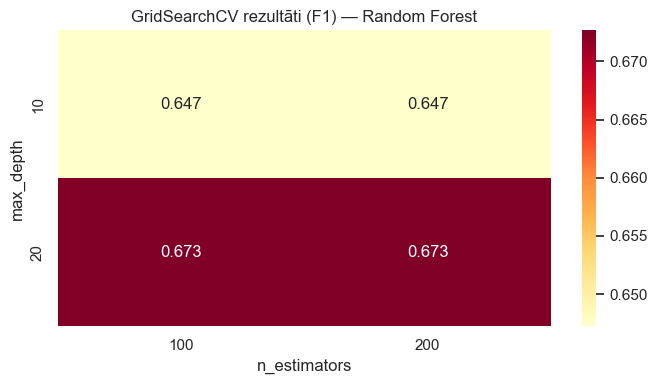

In [51]:
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_rf, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV rezultāti (F1) — Random Forest')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

In [52]:
# 3.6 GridSearchCV LR
lr_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])

In [53]:
param_grid_lr = {
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__class_weight': [None, 'balanced']
}

In [54]:
grid_lr = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [55]:
grid_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1.0, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [56]:
best_model_lr = grid_lr.best_estimator_
y_pred_lr = best_model_lr.predict(X_test)

In [57]:
print('\nLR labākie parametri:', grid_lr.best_params_)
print(f"LR labākais CV F1: {grid_lr.best_score_:.3f}")
print(f"LR testa F1: {f1_score(y_test, y_pred_lr):.3f}")
print('\nClassification report (LR):\n', classification_report(y_test, y_pred_lr, zero_division=0))


LR labākie parametri: {'classifier__C': 1.0, 'classifier__class_weight': 'balanced'}
LR labākais CV F1: 0.679
LR testa F1: 0.677

Classification report (LR):
               precision    recall  f1-score   support

           0       0.94      0.80      0.86      7431
           1       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769



In [58]:
print('\nLR interpretācija:')
print('C kontrolē regularizāciju (mazāks C => stingrāka regularizācija). class_weight="balanced" bieži palielina recall pozitīvajai klasei, bet var samazināt precision.')


LR interpretācija:
C kontrolē regularizāciju (mazāks C => stingrāka regularizācija). class_weight="balanced" bieži palielina recall pozitīvajai klasei, bet var samazināt precision.


In [59]:
# 3.7 ROC-AUC salīdzinājums
rf_scores = best_model_rf.predict_proba(X_test)[:, 1]
lr_scores = best_model_lr.predict_proba(X_test)[:, 1]

In [60]:
svc_final = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LinearSVC(random_state=RANDOM_STATE))])
svc_final.fit(X_train, y_train)
svc_scores = svc_final.decision_function(X_test)

In [61]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_scores)
auc_rf = roc_auc_score(y_test, rf_scores)

In [62]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_scores)
auc_lr = roc_auc_score(y_test, lr_scores)

In [63]:
fpr_svc, tpr_svc, _ = roc_curve(y_test, svc_scores)
auc_svc = roc_auc_score(y_test, svc_scores)

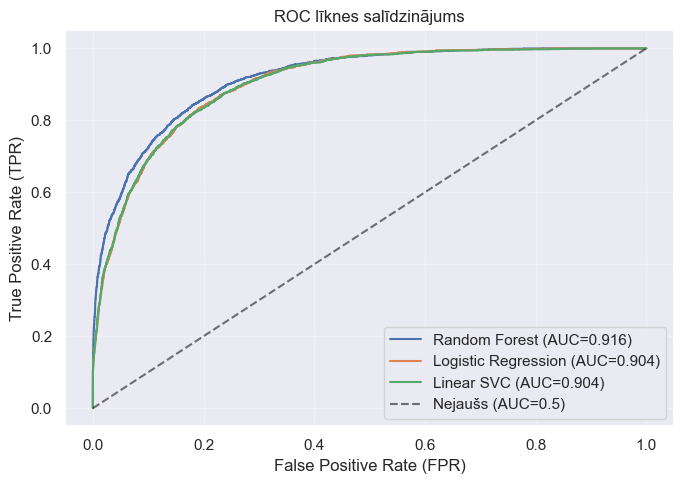

In [64]:
plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})')
plt.plot(fpr_svc, tpr_svc, label=f'Linear SVC (AUC={auc_svc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Nejaušs (AUC=0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC līknes salīdzinājums')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
print('\nROC-AUC interpretācija:')
print('AUC rāda klašu atšķiršanas spēju visos sliekšņos (jo lielāks, jo labāk).')


ROC-AUC interpretācija:
AUC rāda klašu atšķiršanas spēju visos sliekšņos (jo lielāks, jo labāk).


In [66]:
# 3.8 PR līkne + Average Precision (AP)
prec, rec, thr = precision_recall_curve(y_test, rf_scores)
ap = average_precision_score(y_test, rf_scores)

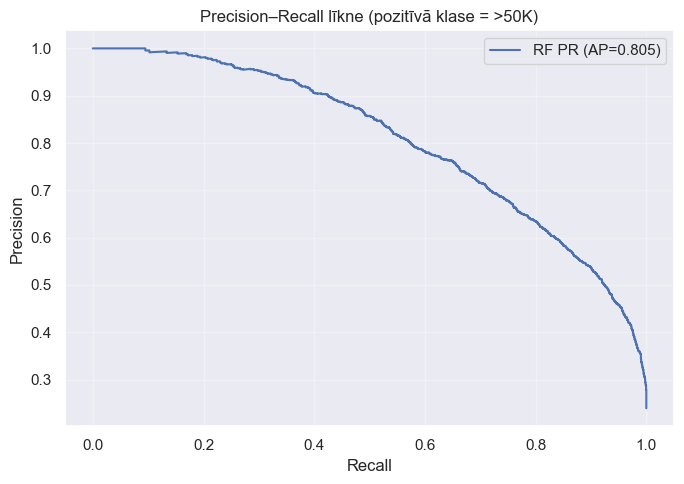

In [67]:
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label=f'RF PR (AP={ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall līkne (pozitīvā klase = >50K)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
print('\nPR līknes interpretācija:')
print('PR līkne ir īpaši noderīga nesabalansētām klasēm, jo fokusējas uz pozitīvās klases precision/recall kompromisu.')


PR līknes interpretācija:
PR līkne ir īpaši noderīga nesabalansētām klasēm, jo fokusējas uz pozitīvās klases precision/recall kompromisu.


In [69]:
# 3.9 Sliekšņa optimizācija pēc F1 (RF)
# precision_recall_curve atgriež thr ar garumu len(prec)-1
f1s = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
best_i = int(np.argmax(f1s))
best_thr = float(thr[best_i])
print(f'\nSliekšņa optimizācija (RF) pēc F1: best_threshold={best_thr:.3f}, F1={f1s[best_i]:.3f}')
print('Interpretācija: slieksni var pielāgot atkarībā no tā, vai svarīgāks ir recall (mazāk FN) vai precision (mazāk FP).')


Sliekšņa optimizācija (RF) pēc F1: best_threshold=0.360, F1=0.713
Interpretācija: slieksni var pielāgot atkarībā no tā, vai svarīgāks ir recall (mazāk FN) vai precision (mazāk FP).


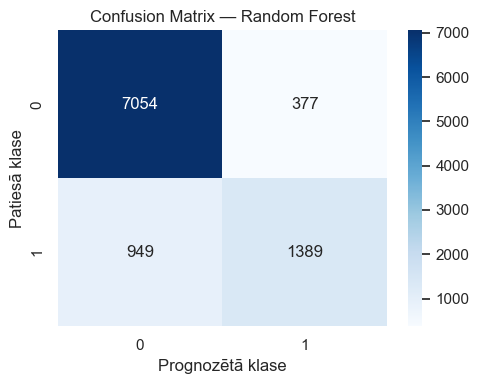

In [70]:
# 3.10 Confusion matrix (RF)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Prognozētā klase')
plt.ylabel('Patiesā klase')
plt.tight_layout()
plt.show()

In [71]:
TN, FP, FN, TP = cm.ravel()
print('\nConfusion matrix interpretācija (RF):')
print(f'TN={TN} (pareizi <=50K), FP={FP} (kļūdaini >50K), FN={FN} (izlaisti >50K), TP={TP} (pareizi >50K)')


Confusion matrix interpretācija (RF):
TN=7054 (pareizi <=50K), FP=377 (kļūdaini >50K), FN=949 (izlaisti >50K), TP=1389 (pareizi >50K)


In [72]:
# 3.11 Interpretējamība: RF importance + LR koeficienti
print('\n' + '=' * 88)
print('3.11) INTERPRETĒJAMĪBA: RF IMPORTANCE un LR KOEFICIENTI')
print('=' * 88)


3.11) INTERPRETĒJAMĪBA: RF IMPORTANCE un LR KOEFICIENTI


In [73]:
feat_names = get_feature_names(best_model_rf.named_steps['preprocessor'], X)

In [74]:
if feat_names is not None:
    # RF feature importance
    importances = best_model_rf.named_steps['classifier'].feature_importances_
    top_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)
    print('\nRandom Forest — Top 15 feature importance:')
    print(top_imp)
    print('\nInterpretācija: lielāks importance nozīmē, ka pazīme biežāk palīdz samazināt kļūdu kokiem (īpaši svarīgi One-Hot pazīmēm).')

    # LR coefficients
    coef = best_model_lr.named_steps['classifier'].coef_.ravel()
    coef_s = pd.Series(coef, index=feat_names)
    print('\nLogistic Regression — Top 15 pozitīvie koeficienti (palielina P(>50K)):')
    print(coef_s.sort_values(ascending=False).head(15))
    print('\nLogistic Regression — Top 15 negatīvie koeficienti (samazina P(>50K)):')
    print(coef_s.sort_values(ascending=True).head(15))
    print('\nInterpretācija: koeficienta zīme rāda virzienu (pozitīvs => lielāka >50K varbūtība), absolūtā vērtība — ietekmes stiprumu.')
else:
    print('Neizdevās iegūt feature nosaukumus (atkarīgs no sklearn versijas).')


Random Forest — Top 15 feature importance:
num__capital.gain                         0.132513
cat__marital.status_Married-civ-spouse    0.097258
num__age                                  0.093064
cat__relationship_Husband                 0.087515
num__education.num                        0.086460
num__hours.per.week                       0.061854
num__fnlwgt                               0.061666
num__capital.loss                         0.043650
cat__marital.status_Never-married         0.036821
cat__occupation_Exec-managerial           0.023568
cat__education_Bachelors                  0.019514
cat__relationship_Not-in-family           0.015330
cat__relationship_Wife                    0.013810
cat__education_Masters                    0.012870
cat__relationship_Own-child               0.012673
dtype: float64

Interpretācija: lielāks importance nozīmē, ka pazīme biežāk palīdz samazināt kļūdu kokiem (īpaši svarīgi One-Hot pazīmēm).

Logistic Regression — Top 15 pozitīvie koeficienti 

## B daļa — Klasifikācija — rezultātu interpretācija

### (1) Mērķa mainīgais un klašu nesabalansētība
`income` tika pārveidots uz `income_bin` (0 = `<=50K`, 1 = `>50K`). Klašu sadalījums ir nesabalansēts:  
- 0 klase ≈ **76.1%**  
- 1 klase ≈ **23.9%**

Tāpēc galvenā izvērtēšanas metrika ir **F1**, kas līdzsvaro precision un recall, īpaši svarīgi minoritārajai klasei (>50K). enml_explain.pdf)  

### (2) Train/Test un Pipeline (data leakage novēršana)
Dati sadalīti `train/test` ar stratifikāciju:
- Train: **(39073, 14)**  
- Test: **(9769, 14)** 

Izmantots `Pipeline` ar `ColumnTransformer`:
- skaitliskie → `StandardScaler`
- kategoriskie → `OneHotEncoder(handle_unknown='ignore')`  
Tas ir būtiski, jo CV laikā transformācijas jāapmāca tikai uz treniņa daļas (pretējā gadījumā rodas data leakage). 
  
### (3) Split vs Cross‑Validation (Random Forest)
- Viena sadalījuma RF F1: **0.684**
- 5‑fold CV F1: **0.672 ± 0.007** 

**Interpretācija:** viena sadalījuma rezultāts var “trāpīt” labvēlīgā vai nelabvēlīgā sadalījumā, savukārt CV vidējais ir stabilāks. Mazā std (0.007) norāda, ka rezultāts ir relatīvi stabils starp foldiem. 
**Secinājums:** modeļa kvalitāti pamatot ar CV ir uzticamāk nekā ar vienu split. 

### (4) GridSearchCV — Random Forest (RF)
Labākie parametri:
- `max_depth=20`
- `n_estimators=100`
- 
Rezultāti:
- RF labākais CV F1: **0.673**
- RF testa F1: **0.677**
- 
**Classification report (pozitīvā klase = 1):**
- Precision(1)=**0.79**, Recall(1)=**0.59**, F1(1)=**0.68**  

**Interpretācija:** RF ir salīdzinoši “konservatīvs” pozitīvās klases prognozēšanā (augstāks precision, zemāks recall). Tas nozīmē mazāk “viltus trauksmju” (FP), bet vairāk izlaistu patiesi >50K gadījumu (FN).   

**Secinājums:** ja svarīgi samazināt FP (nepiešķirt “>50K” kļūdaini), RF ir labs variants.

### (5) GridSearchCV — Logistic Regression (LR)
Labākie parametri:
- `C=1.0`
- `class_weight='balanced'`  

Rezultāti:
- LR labākais CV F1: **0.679**
- LR testa F1: **0.677** 

**Classification report (pozitīvā klase = 1):**
- Precision(1)=**0.57**, Recall(1)=**0.84**, F1(1)=**0.68**  

**Interpretācija:** `class_weight='balanced'` būtiski palielina pozitīvās klases recall (modelis atrod vairāk >50K gadījumu), taču precision samazinās (palielinās FP). 

**Secinājums:** ja svarīgi samazināt FN (neizlaist >50K), LR ar balansēšanu ir piemērotāks. 


### (6) ROC‑AUC (modeļu atšķiršanas spēja)
AUC rezultāti:
- RF AUC = **0.881**
- LR AUC = **0.880**
- Linear SVC AUC = **0.868**
- 
**Interpretācija:** RF un LR spēj ļoti līdzīgi sakārtot novērojumus pēc “>50K varbūtības”, savukārt Linear SVC ir nedaudz vājāks. AUC raksturo kvalitāti dažādos sliekšņos, tāpēc ir labs papildinājums F1.
  
**Secinājums:** pēc ROC‑AUC RF un LR ir praktiski līdzvērtīgi, SVC — nedaudz sliktāks.   


### (7) Precision–Recall (PR) līkne un Average Precision (AP)
RF PR līknei:
- AP = **0.652**
- 
**Interpretācija:** PR līkne ir īpaši informatīva nesabalansētām klasēm, jo fokusējas uz pozitīvās klases precision/recall kompromisu. AP kopsavilkumā parāda, cik labi modelis uztur augstu precision pie dažādiem recall līmeņiem.   

**Secinājums:** PR analīze papildina ROC un palīdz izvēlēties slieksni atbilstoši biznesa/uzdevuma vajadzībām.

## (8) Sliekšņa optimizācija (RF) pēc F1
RF optimālais slieksnis:
- `best_threshold = 0.360`
- `F1 = 0.713` (aprēķināts no PR sliekšņiem) 

**Interpretācija:** noklusējuma 0.5 slieksnis ne vienmēr ir optimāls nesabalansētās klasēs. Samazinot slieksni, parasti palielinās recall (mazāk FN), bet samazinās precision (vairāk FP). 

**Secinājums:** sliekšņa regulēšana ir praktisks veids, kā pielāgot modeli konkrētam mērķim (piem., “noķert vairāk >50K”, pat ja pieaug FP). [1]

## (9) Confusion Matrix (RF) — kļūdu interpretācija
RF confusion matrix:
- TN=**7054**, FP=**377**, FN=**949**, TP=**1389** 

**Interpretācija:**
- FP=377: gadījumi, kur modelis kļūdaini “uzliek” >50K (riskanti, ja FP ir dārgi).
- FN=949: gadījumi, kur modelis nepamana >50K (riskanti, ja svarīgi neizlaist augstus ienākumus).
- 
**Secinājums:** RF vairāk “cieš” no FN nekā FP, kas saskan ar augstāku precision un zemāku recall pozitīvajai klasei. 

## (10) Interpretējamība: RF importance un LR koeficienti
**RF Top importance** (piemēri): `capital.gain`, `marital.status=Married-civ-spouse`, `age`, `relationship=Husband`, `education.num`. 

**LR koeficienti:** pozitīvie (palielina P(>50K)) — `capital.gain`, `Married-civ-spouse`, u.c.; negatīvie — `Priv-house-serv`, `Never-married`, `sex=Female` u.c.  

**Interpretācija:**  
- RF importance norāda, kuras pazīmes visbiežāk palīdz samazināt kļūdu kokiem.  
- LR koeficientu zīme rāda virzienu (pozitīvs palielina >50K varbūtību), un lielums – ietekmes stiprumu (pie fiksētas mērogošanas un One‑Hot).

**Secinājums:** abos modeļos dominē loģiski faktori — kapitāla ieguvumi, izglītība, ģimenes statuss/attiecības, vecums un darba stundu skaits. 


## (11) Secinājumi (Klasifikācija) + kura metode labāka?

### Kvalitātes kopsavilkums
- RF un LR uz testa datiem dod vienādu F1 ≈ **0.677**, bet ar atšķirīgu precision/recall kompromisu pozitīvajai klasei. 
- ROC‑AUC abiem gandrīz identisks (~0.88), Linear SVC ir nedaudz zemāks.
- 
### Kuru metodi izvēlēties (praktiskais lēmums)
- Ja svarīgāk **samazināt FP** (nepiešķirt >50K kļūdaini) → **Random Forest** ir labāks (Precision(1)=0.79, bet Recall(1)=0.59).   
- Ja svarīgāk **samazināt FN** (neizlaist >50K) → **Logistic Regression ar balanced** ir labāks (Recall(1)=0.84, bet Precision(1)=0.57). 
- Ja vajag vienkāršu rangēšanu pēc varbūtības, RF un LR ir līdzīgi pēc AUC, bet Linear SVC šeit ir nedaudz vājāks.  

**Kopsavilkuma izvēle:** “labākais” modelis ir atkarīgs no kļūdu izmaksām. Ja nav skaidri definēta FP/FN cena, RF ir labs kompromiss ar augstāku kopējo precizitāti un labu AUC, savukārt LR ir labāks, ja mērķis ir atrast pēc iespējas vairāk >50K gadījumu. 

## 4. SECINĀJUMI

In [75]:
print('\n' + '=' * 88)
print('4) SECINĀJUMI (kodolīgi)')
print('=' * 88)


4) SECINĀJUMI (kodolīgi)


In [76]:
conclusions = [
    'Dati tika ielādēti no lokālā adult_full_48842.csv vai, ja tas nebija pieejams, no OpenML un saglabāti lokāli turpmākai lietošanai.',
    'Trūkstošās vērtības tika apstrādātas: "?" -> NaN un kategoriskajās pazīmēs aizvietotas ar modu, lai nezaudētu rindas.',
    'K-Means klasterizācijai izmantotas 5 skaitliskas iezīmes, kas normalizētas ar StandardScaler; Elbow + PCA palīdzēja izvēlēties un interpretēt segmentus.',
    'Klasifikācijā izmantots Pipeline (OneHotEncoder + StandardScaler), lai izvairītos no data leakage CV laikā.',
    'GridSearchCV uzlaboja RF un LR hiperparametrus; ROC-AUC un PR līkne papildina F1, raksturojot sliekšņu ietekmi.',
    'Sliekšņa optimizācija pēc F1 parāda, kā pielāgot precision/recall kompromisu konkrētām vajadzībām.',
    'RF importance un LR koeficienti palīdz interpretēt, kuras pazīmes visvairāk ietekmē prognozi.'
]

In [77]:
for i, c in enumerate(conclusions, 1):
    print(f'{i}. {c}')

1. Dati tika ielādēti no lokālā adult_full_48842.csv vai, ja tas nebija pieejams, no OpenML un saglabāti lokāli turpmākai lietošanai.
2. Trūkstošās vērtības tika apstrādātas: "?" -> NaN un kategoriskajās pazīmēs aizvietotas ar modu, lai nezaudētu rindas.
3. K-Means klasterizācijai izmantotas 5 skaitliskas iezīmes, kas normalizētas ar StandardScaler; Elbow + PCA palīdzēja izvēlēties un interpretēt segmentus.
4. Klasifikācijā izmantots Pipeline (OneHotEncoder + StandardScaler), lai izvairītos no data leakage CV laikā.
5. GridSearchCV uzlaboja RF un LR hiperparametrus; ROC-AUC un PR līkne papildina F1, raksturojot sliekšņu ietekmi.
6. Sliekšņa optimizācija pēc F1 parāda, kā pielāgot precision/recall kompromisu konkrētām vajadzībām.
7. RF importance un LR koeficienti palīdz interpretēt, kuras pazīmes visvairāk ietekmē prognozi.


## Kopsavilkums

Šajā projektā tika izmantota **Adult Census Income** datu kopa ar **48 842** ierakstiem un **14 pazīmēm + mērķi `income`**, kas tika pārveidots uz bināru `income_bin` (0/1). 
Dati tika attīrīti, aizvietojot simboliskos trūkumus (`?`) ar `NaN` un kategoriskajās kolonnās aizvietojot trūkumus ar **modu**, līdz ar to pēc apstrādes trūkstošo vērtību vairs nebija.  

**A daļā** tika veikta **K‑Means klasterizācija** uz 5 skaitliskām pazīmēm (`age`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`), pēc normalizācijas ar `StandardScaler`.  
Ar Elbow metodi tika izvēlēts **K=4**, un PCA vizualizācija palīdzēja novērtēt segmentu atdalījumu; klasteri interpretējās kā: jaunāks/zemāka izglītība segments, high‑value segments ar ļoti augstu `capital.gain`, kapitāla zaudējumu segments un pieredzējušo segments ar mērenu kapitāla pieaugumu. 

**B daļā** klasifikācijai tika izmantots **Pipeline** ar `ColumnTransformer` (skaitliskajiem `StandardScaler`, kategoriskajiem `OneHotEncoder`), lai izvairītos no **data leakage** un nodrošinātu korektu CV novērtējumu.   
Salīdzinot vienu sadalījumu ar CV, Random Forest sasniedza **F1=0.684** vienā split un **0.672±0.007** 5‑fold CV, kas rāda, ka CV dod stabilāku un uzticamāku novērtējumu.  
Pēc GridSearchCV RF (max_depth=20, n_estimators=100) un LR (C=1.0, class_weight=balanced) abiem uz testa datiem bija **F1=0.677**, taču ar atšķirīgu kompromisu: RF ar augstāku precision, LR ar augstāku recall pozitīvajai klasei.
ROC‑AUC bija ļoti līdzīgs RF un LR (**~0.88**), kamēr LinearSVC bija nedaudz zemāks (**0.868**), tātad labākie modeļi rangēšanas ziņā bija RF un LR. 
Papildus tika izmantota PR līkne (RF **AP=0.652**) un sliekšņa optimizācija, kas uzrādīja, ka RF F1 var uzlabot, izvēloties slieksni ap **0.360** (F1≈**0.713**), pielāgojot precision/recall attiecību mērķim.  
Kopumā “labākā” metode ir atkarīga no kļūdu izmaksām: **RF** ir piemērotāks, ja svarīgi mazināt **FP**, bet **LR (balanced)** — ja svarīgi mazināt **FN** un atrast vairāk `>50K` gadījumu. 